## **Problem 1**  

**True model**
$$Y_{i}=α+βx_{i}+γw_{i}+δz_{i}+ε_{i} \tag{1}$$ 

**Erroneous model**
$$Y_{i}=α+βx_{i}+γw_{i}+μ_{i} \tag{2}$$

where  $μ_{i}=δz_{i}+ε_{i}$, since $z_{i}$ was omitted from the model.

**1a)** 
<br>
No, the error terms $μ_{i}$ will generally not satisfy the standard assumptions, even if $ε_{i}$ does. In model (2),  $μ_{i}=δz_{i}+ε_{i}$. Even if $ε_{i}$ is uncorrelated with the regressors  $x_{i}$ and  $w_{i}$, it doesn't mean $μ_{i}$ also will not be correlated with $x_{i}$ and/or  $w_{i}$, unless $z_{i}$ is uncorrelated with $x_{i}$ and $w_{i}$. If  $z_{i}$ is correlated with either $x_{i}$ or $w_{i}$, then $μ_{i}$ is not independent or uncorrelated with the regressors, violating the standard assumption of zero conditional mean  $E[μ_{i}∣x_{i},w_{i}]=0$. This leads to omitted variable bias.

**1b)** 
<br>
The estimates from model (2) will generally be biased and inconsistent for 
$α, β,$ and $γ$. Model (2) omits $z_{i}$, which is part of the true data-generating process. As a result:

- If  $z_{i}$ is correlated with any of the included regressors ($x_{i},  w_{i}$), then the estimated coefficients $\hat{\beta}$, $\hat{\gamma}$ and $\hat{\alpha}$ from model (2) will absorb part of the effect of  $z_{i}$, resulting in biased estimates. 
- $δ$ is not estimated at all in model (2) since  $z_{i}$ is excluded.

**1c)** 
<br>
The estimates from model (2) would be the same as those from model (1) if and only if $z_{i}$ is uncorrelated with both $x_{i}$ and $w_{i}$ (i.e.,  $Cov(z_{i},x_{i})=0$ and $Cov(z_{i},w_{i})=0$).

If  $z_{i}$ is uncorrelated with all included regressors, then omitting it does not cause bias in the estimation of the coefficients $α, β,$ and $γ$. In that special case, the omitted variable behaves like part of the error term that satisfies the standard OLS assumptions, and the estimators remain unbiased.

**1d)**
<br>
To explore the effect of omitting a relevant predictor in a regression model, I simulated data $Y_i$ from a known model with two predictors: $X_i, Z_i$, where the predictors are correlated (as requested in the assignment). 
<br>The model is:

$$ Y_i = 1 + 2 X_i + 3 Z_i + e_i \tag{3}$$

where

- $a = 1$
- $b = 2$
- $c = 3$
- $e_i ~ N(0,1)$ is standard normal noise
- $X$ and $Z$ are generated to be correlated 

**Simulation Steps:**  
In attached .ipynb, I did the following steps:

- Generated $n$ samples of $X$ from a standard normal distribution 
- Generate $Z$ as $Z = 0.8X + 0.6u$, where $u$ is standard normal and independent of $X$ (so $X$ and $Z$ are correlated)  
- Generated $Y$ using the model above  
- Fitted two regression models:  
  1. Full model:    $Y$ on $X$ and $Z$ (with both predictors)  
  2. Reduced model: $Y$ on $X$ only (omitted $Z$)  
- Compared the estimated coefficient for $X$ in both models  
- Repeated for different sample sizes (100 vs 1000) 

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

np.random.seed(42)

def simulate_and_compare(n=100):
    a, b, c = 1, 2, 3
    X = np.random.normal(0, 1, n)
    u = np.random.normal(0, 1, n)
    Z = 0.8 * X + 0.6 * u  # X and Z are correlated
    e = np.random.normal(0, 1, n)
    Y = a + b * X + c * Z + e
    
    # Full model
    XZ = np.column_stack([X, Z])
    model_full = LinearRegression().fit(XZ, Y)
    b_hat_full = model_full.coef_[0]
    c_hat_full = model_full.coef_[1]
    
    # Reduced model (omit Z)
    model_reduced = LinearRegression().fit(X.reshape(-1, 1), Y)
    b_hat_reduced = model_reduced.coef_[0]
    
    return b_hat_full, c_hat_full, b_hat_reduced

# Try with n=100
b_full, c_full, b_reduced = simulate_and_compare(n=100)
print(f"n=100:  Full model b_hat = {b_full:.2f}, c_hat = {c_full:.2f}; Reduced model b_hat = {b_reduced:.2f}")

# Try with n=1000
b_full2, c_full2, b_reduced2 = simulate_and_compare(n=1000)
print(f"n=1000: Full model b_hat = {b_full2:.2f}, c_hat = {c_full2:.2f}; Reduced model b_hat = {b_reduced2:.2f}")

n=100:  Full model b_hat = 2.24, c_hat = 2.98; Reduced model b_hat = 4.37
n=1000: Full model b_hat = 2.00, c_hat = 3.03; Reduced model b_hat = 4.37


**Discussion:**

When both $X$ and $Z$ are included in the model, the estimated coefficients ($b$ and $c$) are close to their true values. However, when $Z$ is omitted, the estimated coefficient for $X$ in the reduced model is biased and does not reflect the true value of $b$. This is due to omitted variable bias, which occurs when a relevant predictor that is correlated with the included predictor is left out of the model. Increasing the sample size reduces the variance of the estimates, but the bias in the reduced model remains. This simulation demonstrates the importance of including all relevant predictors in a regression model, especially when predictors are correlated.


## Problem 2
**2a)**
<br>
Regression models, such as OLS linear regression, are widely used for modeling relationships between variables. But, one of the key limitations of many regression techniques is their sensitivity to outliers and high leverage data points that deviate significantly from the general pattern of the data. Outliers can be: measurement errors, data entry mistakes, or real one time events. Regardless of their origin, outliers can significantly affect the results of regression analysis and reduce explanatory power of the model.

For example, in case of OLS regression, the model estimates coefficients by minimizing the sum of squared residuals (the differences between observed and predicted values). Because the residuals are squared, large deviations (i.e., outliers and high leverage points) will distort the results. Even a single outlier can pull the regression line toward itself, and distort the estimated relationship between variables. This can lead to biased or misleading coefficient estimates, inflated standard errors, and reduced predictive accuracy.

The influence of outliers is not limited to the estimated coefficients. Outliers can also affect diagnostic measures such as R-squared, residual plots, and tests for model assumptions (e.g., normality and homoscedasticity of residuals). In some cases, outliers may mask or exaggerate relationships, making it difficult to detect true patterns in the data.

To address the sensitivity to outliers and high leverage points, analysts should carefully analyze the origination of the points, and decide on proper handling. They can use data transformations, or outlier detection and removal. Ultimately, careful data exploration and understanding of the context are essential for making informed decisions about handling outliers in regression analysis.


**2b)** 

**Simulation Setup:**
- Suppose we have following linear relationship:  
  $$ y_i = 1 + 3x_i + \epsilon_i $$ 

  where

- $x_i$ is drawn from a uniform distribution    
- $\epsilon_i$ ~ N(0,1)

In attached .ipynb, I did the following steps:
- I generated 30 data points for $x$ and $\epsilon_i$
- I fitted an OLS model to this data to estimate the slope and intercept.
- Next, I introduced 3 outliers by replacing the last three $y$ values with outliers (e.g., -20, 25, -30)
- I refitted the OLS model to the data with outliers and compared the estimated parameters to those from the original data.

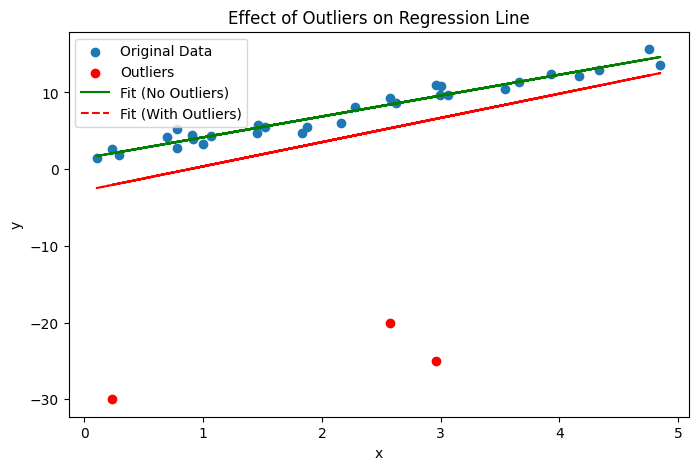

No Outliers:   Slope = 2.72, Intercept = 1.43
With Outliers: Slope = 3.16, Intercept = -2.79


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n = 30
x = np.random.uniform(0, 5, n)
y = 1 + 3 * x + np.random.normal(0, 1, n)
X = x.reshape(-1,1)

# Fit regression without outliers
model_clean = LinearRegression()
model_clean.fit(X, y)

# Introduce outliers
y_outliers = y.copy()
y_outliers[-3:] = [-20, -25, -30]

# Fit regression with outliers
model_outliers = LinearRegression()
model_outliers.fit(X, y_outliers)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Original Data")
plt.scatter(x[-3:], y_outliers[-3:], color='red', label="Outliers", zorder=5)
plt.plot(x, model_clean.predict(x.reshape(-1, 1)), label="Fit (No Outliers)", color='green')
plt.plot(x, model_outliers.predict(x.reshape(-1, 1)), label="Fit (With Outliers)", color='red', linestyle='--')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of Outliers on Regression Line")
plt.show()

print(f"No Outliers:   Slope = {model_clean.coef_[0]:.2f}, Intercept = {model_clean.intercept_:.2f}")
print(f"With Outliers: Slope = {model_outliers.coef_[0]:.2f}, Intercept = {model_outliers.intercept_:.2f}")

**Discussion:**

The plot above shows the regression lines with and without outliers. The presence of just a few extreme outliers shifts the regression line, resulting in a steeper slope and a much higher intercept. The printed coefficients quantify this effect, with the original (without outliers) regression results being closer to the true coefficients, while the model with outliers deviates significantly from the true coefficients. This simulation demonstrates how sensitive OLS regression is to outliers and highlights the importance of detecting and addressing outliers in real-world data analysis.

## **Problem 3**  